# NeuralMag cube with differentiable surface layer

This notebook mirrors the MuMax cube/surface setup with NeuralMag's BB/Cayley steepest-descent minimizer. It first compares `surface = 0 nm` and `surface = 5 nm`, then provides a differentiable phase-fitting path for the surface saturation magnetization and shell thickness.

The surface thickness parameter follows the pasted MuMax convention: `D = D_total - surface_nm`. For a centered cube this means the physical thickness on each face is `surface_nm / 2`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from functools import lru_cache
from pathlib import Path
import os
import sys
import time

# These must be set before JAX and NeuralMag initialize their backends.
os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.2")

import matplotlib.pyplot as plt
import numpy as np
import optax
import jax
import jax.numpy as jnp
import unxt as u

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for extra_path in (repo_root / "src", repo_root / "vendor" / "neuralmag"):
    if extra_path.exists() and str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires NeuralMag. Use the repo notebook environment "
        "or the vendored NeuralMag path."
    ) from exc

nm.config.dtype = "float64"
try:
    _ = nm.config.backend
    backend_name = getattr(getattr(nm, "config", None), "backend", None)
    backend_name = getattr(backend_name, "name", backend_name)
except Exception as exc:
    raise RuntimeError("NeuralMag needs a working backend before this notebook can run.") from exc

from libertem_holo.base.mbir import MU_0, build_rdfc_kernel, forward_phase_from_density_and_magnetization

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {backend_name}")

2026-04-28 14:13:46 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-28 14:13:47 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-28 14:13:47 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


In [2]:
@dataclass(frozen=True)
class CubeSurfaceConfig:
    n: int = 100
    d_total_nm: float = 100.0
    cellsize_nm: float = 1.0
    phase_pad_px: int = 32
    boundary_softness_nm: float = 0.2
    ms_core_a_per_m: float = 480e3
    ms_surface_a_per_m: float = 100e3
    aex_j_per_m: float = 1e-11
    kc_core_j_per_m3: float = -1.3e4
    demag_p: int = 3
    initial_ovf_path: Path | None = None
    random_surface_seed: int = 21
    vortex_circulation: int = 1
    vortex_polarization: int = -1
    vortex_core_radius_nm: float = 10.0
    minimizer_tol: float = 1e3
    minimizer_max_iter: int = 20000
    minimizer_tau_min: float = 1e-18
    minimizer_tau_max: float = 1e-4


ovf_initial_path = repo_root / "notebooks" / "MBIR" / "vortex_cube_128_111.ovf"
full_config = CubeSurfaceConfig(initial_ovf_path=ovf_initial_path)
debug_config = replace(
    full_config,
    n=24,
    d_total_nm=24.0,
    phase_pad_px=8,
    initial_ovf_path=None,
    demag_p=1,
    vortex_core_radius_nm=4.0,
    minimizer_max_iter=20000,
)

comparison_surface_nm_values = (0.0, 5.0)
output_dir = repo_root / "notebooks" / "MBIR" / "neuralmag_cube_surface_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# The full 100^3 relaxation is the MuMax-like target. Use debug_config first
# when checking a new machine or CPU-only environment.
config = full_config
print(config)
print(f"Surface parameter 5 nm means {5.0 / 2.0:g} nm per face for centered cubes.")

CubeSurfaceConfig(n=100, d_total_nm=100.0, cellsize_nm=1.0, phase_pad_px=32, boundary_softness_nm=0.2, ms_core_a_per_m=480000.0, ms_surface_a_per_m=100000.0, aex_j_per_m=1e-11, kc_core_j_per_m3=-13000.0, demag_p=3, random_surface_seed=21, vortex_circulation=1, vortex_polarization=-1, vortex_core_radius_nm=10.0, minimizer_tol=1000.0, minimizer_max_iter=20000, minimizer_tau_min=1e-18, minimizer_tau_max=0.0001)
Surface parameter 5 nm means 2.5 nm per face for centered cubes.


## Geometry and initial magnetization

The differentiable shell uses a sigmoid-smoothed inner cube. For plotting and MuMax-like contours, hard cube masks are still available.

`full_config` warm-starts from `vortex_cube_128_111.ovf` when it is present. The OVF is center-cropped from `128^3` to the configured `100^3` NeuralMag grid, then blended with the seeded random surface shell just like the MuMax region setup.

In [3]:
def cell_centered_axes(config: CubeSurfaceConfig):
    n = int(config.n)
    dx = float(config.cellsize_nm)
    axis = (np.arange(n, dtype=np.float64) + 0.5) * dx - (n * dx / 2.0)
    return np.meshgrid(axis, axis, axis, indexing="ij")


def cell_centered_axes_jax(config: CubeSurfaceConfig, dtype=jnp.float64):
    n = int(config.n)
    dx = jnp.asarray(config.cellsize_nm, dtype=dtype)
    axis = (jnp.arange(n, dtype=dtype) + 0.5) * dx - (n * dx / 2.0)
    return jnp.meshgrid(axis, axis, axis, indexing="ij")


def smooth_inner_cube_weight_jax(surface_nm, config: CubeSurfaceConfig):
    """Differentiable approximation of the MuMax inner cuboid mask."""
    xx, yy, zz = cell_centered_axes_jax(config)
    max_abs = jnp.maximum(jnp.maximum(jnp.abs(xx), jnp.abs(yy)), jnp.abs(zz))
    inner_edge = jnp.asarray(config.d_total_nm, dtype=max_abs.dtype) - jnp.asarray(surface_nm, dtype=max_abs.dtype)
    inner_edge = jnp.maximum(inner_edge, jnp.asarray(0.0, dtype=max_abs.dtype))
    half_extent = 0.5 * inner_edge
    # The half-cell offset makes threshold(weight > 0.5) reproduce an integer-cell cuboid.
    signed_margin = half_extent - max_abs + 0.5 * config.cellsize_nm
    return jax.nn.sigmoid(signed_margin / config.boundary_softness_nm)


def cube_weights_jax(surface_nm, config: CubeSurfaceConfig):
    core_weight = smooth_inner_cube_weight_jax(surface_nm, config)
    surface_weight = 1.0 - core_weight
    return core_weight, surface_weight


def cube_weights_np(surface_nm: float, config: CubeSurfaceConfig, *, exact_zero_surface: bool = True):
    if exact_zero_surface and abs(float(surface_nm)) < 1e-12:
        core = np.ones((config.n, config.n, config.n), dtype=np.float64)
        surface = np.zeros_like(core)
        return core, surface
    core = np.asarray(cube_weights_jax(float(surface_nm), config)[0])
    return core, 1.0 - core


def hard_inner_cube_mask(surface_nm: float, config: CubeSurfaceConfig):
    xx, yy, zz = cell_centered_axes(config)
    inner_edge = max(float(config.d_total_nm) - float(surface_nm), 0.0)
    half_extent = 0.5 * inner_edge
    max_abs = np.maximum.reduce([np.abs(xx), np.abs(yy), np.abs(zz)])
    return max_abs <= (half_extent - 0.5 * config.cellsize_nm + 1e-9)


def center_crop_xyz(values, target_shape_xyz):
    values = np.asarray(values)
    target_shape_xyz = tuple(int(v) for v in target_shape_xyz)
    if any(src < dst for src, dst in zip(values.shape[:3], target_shape_xyz)):
        raise ValueError(f"Cannot center-crop shape {values.shape[:3]} to larger shape {target_shape_xyz}.")
    starts = tuple((src - dst) // 2 for src, dst in zip(values.shape[:3], target_shape_xyz))
    stops = tuple(start + dst for start, dst in zip(starts, target_shape_xyz))
    spatial_slices = tuple(slice(start, stop) for start, stop in zip(starts, stops))
    return values[spatial_slices + (slice(None),)] if values.ndim == 4 else values[spatial_slices]


@lru_cache(maxsize=4)
def read_ovf_text_magnetization(path_str: str):
    path = Path(path_str)
    header = {}
    with path.open("r", encoding="utf-8") as stream:
        for line in stream:
            stripped = line.strip()
            if stripped.startswith("# Begin: Data Text"):
                break
            if not stripped.startswith("#") or ":" not in stripped:
                continue
            key, value = stripped[1:].split(":", 1)
            header[key.strip().lower()] = value.strip()

    xnodes = int(header["xnodes"])
    ynodes = int(header["ynodes"])
    znodes = int(header["znodes"])
    valuedim = int(header.get("valuedim", "3"))
    if valuedim != 3:
        raise ValueError(f"Expected OVF valuedim=3, got {valuedim} in {path}.")

    data = np.loadtxt(path, comments="#", dtype=np.float64)
    expected_rows = xnodes * ynodes * znodes
    if data.shape != (expected_rows, valuedim):
        raise ValueError(f"Expected OVF data shape {(expected_rows, valuedim)}, got {data.shape}.")

    # OVF text order has x varying fastest, then y, then z.
    m_zyx = data.reshape((znodes, ynodes, xnodes, valuedim))
    m_xyz = np.transpose(m_zyx, (2, 1, 0, 3))
    return m_xyz, header


def initial_magnetization_from_ovf(config: CubeSurfaceConfig):
    if config.initial_ovf_path is None:
        return None
    path = Path(config.initial_ovf_path)
    if not path.exists():
        print(f"OVF initial state not found, using analytic seed: {path}")
        return None

    m_xyz, header = read_ovf_text_magnetization(str(path.resolve()))
    if m_xyz.shape[:3] != (config.n, config.n, config.n):
        m_xyz = center_crop_xyz(m_xyz, (config.n, config.n, config.n))
    print(f"Using OVF initial magnetization {path.name}: {header['xnodes']}x{header['ynodes']}x{header['znodes']} -> {config.n}^3")
    return normalize_on_support(m_xyz, np.ones((config.n, config.n, config.n)))


def orthonormalize_axes(axis1, axis2):
    axis1 = np.asarray(axis1, dtype=np.float64)
    axis1 = axis1 / np.linalg.norm(axis1)
    axis2 = np.asarray(axis2, dtype=np.float64)
    axis2 = axis2 - np.dot(axis2, axis1) * axis1
    axis2 = axis2 / np.linalg.norm(axis2)
    axis3 = np.cross(axis1, axis2)
    axis3 = axis3 / np.linalg.norm(axis3)
    return axis1, axis2, axis3


def normalize_on_support(m_xyz, support_weight, threshold=1e-6):
    m_xyz = np.asarray(m_xyz, dtype=np.float64)
    support = np.asarray(support_weight) > threshold
    norms = np.linalg.norm(m_xyz, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    return np.where(support[..., None], m_xyz / safe_norms, 0.0)


def make_vortex_seed(config: CubeSurfaceConfig):
    xx, yy, _ = cell_centered_axes(config)
    phi = np.arctan2(yy, xx)
    radius = np.sqrt(xx * xx + yy * yy)
    mz = float(config.vortex_polarization) * np.exp(-(radius / config.vortex_core_radius_nm) ** 2)
    in_plane = np.sqrt(np.maximum(1.0 - mz * mz, 0.0))
    m = np.zeros((config.n, config.n, config.n, 3), dtype=np.float64)
    m[..., 0] = -float(config.vortex_circulation) * np.sin(phi) * in_plane
    m[..., 1] = float(config.vortex_circulation) * np.cos(phi) * in_plane
    m[..., 2] = mz
    return m


def make_random_seed(config: CubeSurfaceConfig):
    rng = np.random.default_rng(config.random_surface_seed)
    return rng.normal(size=(config.n, config.n, config.n, 3))


def make_initial_magnetization(surface_nm: float, config: CubeSurfaceConfig):
    core_weight, surface_weight = cube_weights_np(surface_nm, config)
    ovf_initial = initial_magnetization_from_ovf(config)
    vortex = ovf_initial if ovf_initial is not None else make_vortex_seed(config)
    random = make_random_seed(config)
    m = core_weight[..., None] * vortex + surface_weight[..., None] * random
    return normalize_on_support(m, np.ones_like(core_weight))


def material_fields_np(surface_nm: float, ms_surface_a_per_m: float, config: CubeSurfaceConfig):
    core_weight, surface_weight = cube_weights_np(surface_nm, config)
    ms = core_weight * config.ms_core_a_per_m + surface_weight * float(ms_surface_a_per_m)
    kc = core_weight * config.kc_core_j_per_m3
    return core_weight, surface_weight, ms, kc


def material_fields_jax(surface_nm, ms_surface_a_per_m, config: CubeSurfaceConfig):
    core_weight, surface_weight = cube_weights_jax(surface_nm, config)
    ms = core_weight * config.ms_core_a_per_m + surface_weight * ms_surface_a_per_m
    kc = core_weight * config.kc_core_j_per_m3
    return core_weight, surface_weight, ms, kc


axis1, axis2, axis3 = orthonormalize_axes([1.0, 1.0, 1.0], [1.0, -1.0, 0.0])
print("Cubic axes:", axis1, axis2, axis3)

Cubic axes: [0.57735 0.57735 0.57735] [ 0.70711 -0.70711  0.     ] [ 0.40825  0.40825 -0.8165 ]


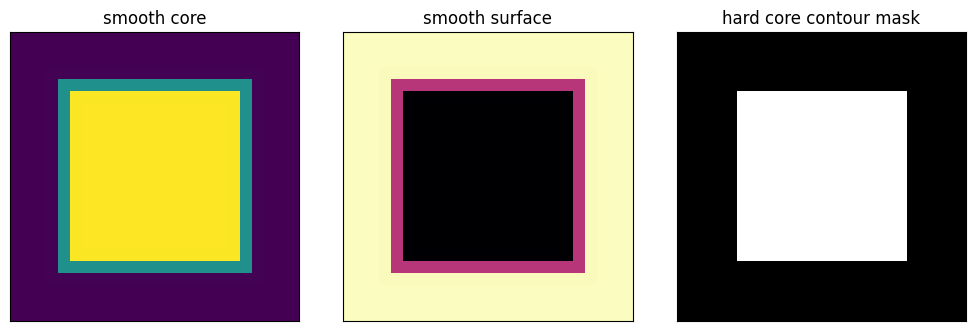

In [4]:
def show_shell_weights(surface_nm: float, config: CubeSurfaceConfig):
    core_weight, surface_weight = cube_weights_np(surface_nm, config)
    hard_core = hard_inner_cube_mask(surface_nm, config)
    mid = config.n // 2
    fig, axs = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
    axs[0].imshow(core_weight[:, :, mid].T, cmap="viridis", vmin=0.0, vmax=1.0)
    axs[0].set_title("smooth core")
    axs[1].imshow(surface_weight[:, :, mid].T, cmap="magma", vmin=0.0, vmax=1.0)
    axs[1].set_title("smooth surface")
    axs[2].imshow(hard_core[:, :, mid].T, cmap="gray", vmin=0.0, vmax=1.0)
    axs[2].set_title("hard core contour mask")
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()


show_shell_weights(5.0, debug_config)

## NeuralMag relaxation and MBIR phase

`EnergyMinimizer.solve_fixed` is used for the differentiable path. The comparison figures use the same minimizer family and return the final magnetization, phase, and support contours.

`phase_pad_px` pads the projected Y/X phase view before the MBIR forward model, so the phase images include extra space around the cube without increasing the 3D NeuralMag relaxation grid.

In [5]:
def constant_vector_cell_function(state, shape_xyz, vector):
    values = np.broadcast_to(np.asarray(vector, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def normalize_jax(m_xyz, support_weight):
    support = (jnp.asarray(support_weight, dtype=m_xyz.dtype) > 1e-6).astype(m_xyz.dtype)[..., None]
    eps = jnp.finfo(m_xyz.dtype).eps
    norm = jnp.sqrt(jnp.sum(m_xyz * m_xyz, axis=-1, keepdims=True) + eps * eps)
    return support * m_xyz / norm


def build_state_template(config: CubeSurfaceConfig, m0_cell_xyz, ms_field, kc_field):
    state = nm.State(nm.Mesh((config.n, config.n, config.n), (config.cellsize_nm * 1e-9,) * 3))
    rho_min = float(getattr(state, "eps", 1e-12))
    rho = np.ones((config.n, config.n, config.n), dtype=np.float64)
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.clip(rho, rho_min, 1.0), dtype=state.dtype))
    state.material.Ms = nm.CellFunction(state, tensor=state.tensor(ms_field, dtype=state.dtype))
    state.material.A = nm.CellFunction(state).fill(config.aex_j_per_m)
    state.material.Kc = nm.CellFunction(state, tensor=state.tensor(kc_field, dtype=state.dtype))
    state.material.Kc_axis1 = constant_vector_cell_function(state, (config.n, config.n, config.n), axis1)
    state.material.Kc_axis2 = constant_vector_cell_function(state, (config.n, config.n, config.n), axis2)
    state.material.Kc_axis3 = constant_vector_cell_function(state, (config.n, config.n, config.n), axis3)
    state.m = nm.VectorCellFunction(state, tensor=state.tensor(m0_cell_xyz, dtype=state.dtype))

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=config.demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


def make_minimizer(state, config: CubeSurfaceConfig, *, parameterized: bool):
    kwargs = dict(
        method="alternating",
        update="cayley",
        tol=config.minimizer_tol,
        max_iter=config.minimizer_max_iter,
        tau_min=config.minimizer_tau_min,
        tau_max=config.minimizer_tau_max,
        projection=lambda m: normalize_jax(m, state.rho.tensor),
    )
    if parameterized:
        kwargs["parameters"] = ["material__Ms", "material__Kc"]
    return nm.EnergyMinimizer(state, **kwargs)


def xyz_to_zyx(values):
    array = np.asarray(values)
    axes = (2, 1, 0) if array.ndim == 3 else (2, 1, 0, 3)
    return np.transpose(array, axes)


def phase_view_shape(config: CubeSurfaceConfig):
    pad = int(config.phase_pad_px)
    return (config.n + 2 * pad, config.n + 2 * pad)


def pad_phase_view_zyx(values, config: CubeSurfaceConfig):
    pad = int(config.phase_pad_px)
    if pad <= 0:
        return values
    if values.ndim == 3:
        return jnp.pad(values, ((0, 0), (pad, pad), (pad, pad)))
    return jnp.pad(values, ((0, 0), (pad, pad), (pad, pad), (0, 0)))


def pad_phase_mask_yx(values_xy, config: CubeSurfaceConfig):
    values_yx = np.asarray(values_xy).T
    pad = int(config.phase_pad_px)
    if pad <= 0:
        return values_yx
    return np.pad(values_yx, ((pad, pad), (pad, pad)), mode="constant")


def phase_from_cell_m_jax(m_cell_xyz, ms_field_xyz, config: CubeSurfaceConfig, rdfc_kernel=None):
    m_cell_xyz = normalize_jax(jnp.asarray(m_cell_xyz), jnp.ones((config.n, config.n, config.n)))
    ms_field_xyz = jnp.asarray(ms_field_xyz, dtype=m_cell_xyz.dtype)
    rho_zyx = jnp.ones((config.n, config.n, config.n), dtype=m_cell_xyz.dtype)
    rho_zyx = jnp.transpose(rho_zyx, (2, 1, 0))
    m_zyx = jnp.transpose(m_cell_xyz, (2, 1, 0, 3))
    ms_zyx = jnp.transpose(ms_field_xyz, (2, 1, 0))
    magnetization_zyx = m_zyx * (jnp.asarray(MU_0.value, dtype=m_cell_xyz.dtype) * ms_zyx[..., None])
    rho_zyx = pad_phase_view_zyx(rho_zyx, config)
    magnetization_zyx = pad_phase_view_zyx(magnetization_zyx, config)
    if rdfc_kernel is None:
        rdfc_kernel = build_rdfc_kernel(phase_view_shape(config), geometry="disc", dtype=m_cell_xyz.dtype)
    return forward_phase_from_density_and_magnetization(
        rho=rho_zyx,
        magnetization_3d=magnetization_zyx,
        pixel_size=u.Quantity(float(config.cellsize_nm), "nm"),
        projection_step_size=u.Quantity(float(config.cellsize_nm), "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_kernel,
    )


def phase_from_cell_m_np(m_cell_xyz, ms_field_xyz, config: CubeSurfaceConfig):
    phase = phase_from_cell_m_jax(
        jnp.asarray(m_cell_xyz, dtype=jnp.float64),
        jnp.asarray(ms_field_xyz, dtype=jnp.float64),
        config,
    )
    return np.asarray(jax.device_get(phase), dtype=np.float64)


def relax_cube_case(surface_nm: float, config: CubeSurfaceConfig, *, ms_surface_a_per_m: float | None = None):
    ms_surface = config.ms_surface_a_per_m if ms_surface_a_per_m is None else float(ms_surface_a_per_m)
    core_weight, surface_weight, ms_field, kc_field = material_fields_np(surface_nm, ms_surface, config)
    m0 = make_initial_magnetization(surface_nm, config)
    state = build_state_template(config, m0, ms_field, kc_field)
    minimizer = make_minimizer(state, config, parameterized=False)

    started = time.perf_counter()
    max_g, info = minimizer.minimize(return_info=True)
    elapsed_s = time.perf_counter() - started

    m_final = normalize_on_support(np.asarray(state.m.tensor), np.ones((config.n, config.n, config.n)))
    phase = phase_from_cell_m_np(m_final, ms_field, config)
    return {
        "surface_nm": float(surface_nm),
        "config": config,
        "per_face_shell_nm": float(surface_nm) / 2.0,
        "ms_surface_a_per_m": ms_surface,
        "core_weight": core_weight,
        "surface_weight": surface_weight,
        "ms_field": ms_field,
        "kc_field": kc_field,
        "m0": m0,
        "m": m_final,
        "phase": phase,
        "max_g": float(np.asarray(max_g)),
        "n_iter": int(np.asarray(info["n_iter"])),
        "converged": bool(np.asarray(info["converged"])),
        "elapsed_s": elapsed_s,
    }

In [ ]:
# Tiny smoke test for finite relaxation and phase generation.
debug_results = []
for surface_nm in (0.0, 5.0):
    print(f"Debug relaxation surface={surface_nm:g} nm ...")
    result = relax_cube_case(surface_nm, debug_config)
    debug_results.append(result)
    print(
        f"  n_iter={result['n_iter']} converged={result['converged']} "
        f"max_g={result['max_g']:.3g} phase=[{result['phase'].min():.3g}, {result['phase'].max():.3g}] "
        f"elapsed={result['elapsed_s']:.2f}s"
    )

fig, axs = plt.subplots(1, 2, figsize=(7.5, 3.3), constrained_layout=True)
phase_lim = max(max(abs(r["phase"].min()), abs(r["phase"].max())) for r in debug_results)
for ax, result in zip(axs, debug_results):
    im = ax.imshow(result["phase"], cmap="viridis", vmin=-phase_lim, vmax=phase_lim)
    ax.set_title(f"debug surface = {result['surface_nm']:.0f} nm")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axs, fraction=0.046, label="rad")
plt.show()

2026-04-28 14:13:48 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-28 14:13:48 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 14:13:48 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-28 14:13:48 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-28 14:13:48 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-28 14:13:48 NeuralMag:INFO [DemagField]: Set up demag tensor


Debug relaxation surface=0 nm ...


2026-04-28 14:13:52 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-28 14:13:52 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


In [ ]:
# Full MuMax-like comparison. This can take a while on CPU.
run_full_comparison = True

comparison_results = []
if run_full_comparison:
    for surface_nm in comparison_surface_nm_values:
        print(f"Full relaxation surface={surface_nm:g} nm ...")
        result = relax_cube_case(surface_nm, config)
        comparison_results.append(result)
        print(
            f"  n_iter={result['n_iter']} converged={result['converged']} "
            f"max_g={result['max_g']:.3g} elapsed={result['elapsed_s']:.2f}s"
        )

if comparison_results:
    np.savez_compressed(
        output_dir / "cube_surface_comparison.npz",
        **{f"phase_surface_{int(r['surface_nm'])}nm": r["phase"] for r in comparison_results},
        **{f"m_surface_{int(r['surface_nm'])}nm": r["m"] for r in comparison_results},
    )

2026-04-28 14:09:35 NeuralMag:INFO [Mesh] 3D, 100 x 100 x 100 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-28 14:09:35 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 14:09:35 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-28 14:09:35 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-28 14:09:35 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-28 14:09:35 NeuralMag:INFO [DemagField]: Set up demag tensor


Full relaxation surface=0 nm ...


2026-04-28 14:09:37 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-28 14:09:37 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-28 14:09:44 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energy E = 2.83601e-17 J
2026-04-28 14:10:10 NeuralMag:INFO [EnergyMinimizerJAX] Initial state 0/10000: max_g = 219281 (tol = 1000, converged = False)
2026-04-28 14:11:21 NeuralMag:INFO [EnergyMinimizerJAX] Final state 10000/10000: max_g = 10236.6 (tol = 1000, converged = False)
2026-04-28 14:11:21 NeuralMag:INFO [EnergyMinimizerJAX] Minimization finished after 10000 steps, final energy E = 3.90661e-19 J, converged = False
2026-04-28 14:11:21 NeuralMag:INFO [Mesh] 3D, 100 x 100 x 100 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-28 14:11:21 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 14:11:21 NeuralMag:INFO [State] Running 

  n_iter=10000 converged=False max_g=1.02e+04 elapsed=103.82s
Full relaxation surface=10 nm ...


2026-04-28 14:11:23 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-28 14:11:23 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-28 14:11:30 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energy E = 9.43199e-16 J
2026-04-28 14:12:02 NeuralMag:INFO [EnergyMinimizerJAX] Initial state 0/10000: max_g = 1.39026e+08 (tol = 1000, converged = False)
2026-04-28 14:13:20 NeuralMag:INFO [EnergyMinimizerJAX] Final state 10000/10000: max_g = 38508.3 (tol = 1000, converged = False)
2026-04-28 14:13:20 NeuralMag:INFO [EnergyMinimizerJAX] Minimization finished after 10000 steps, final energy E = 2.17866e-19 J, converged = False


  n_iter=10000 converged=False max_g=3.85e+04 elapsed=116.37s


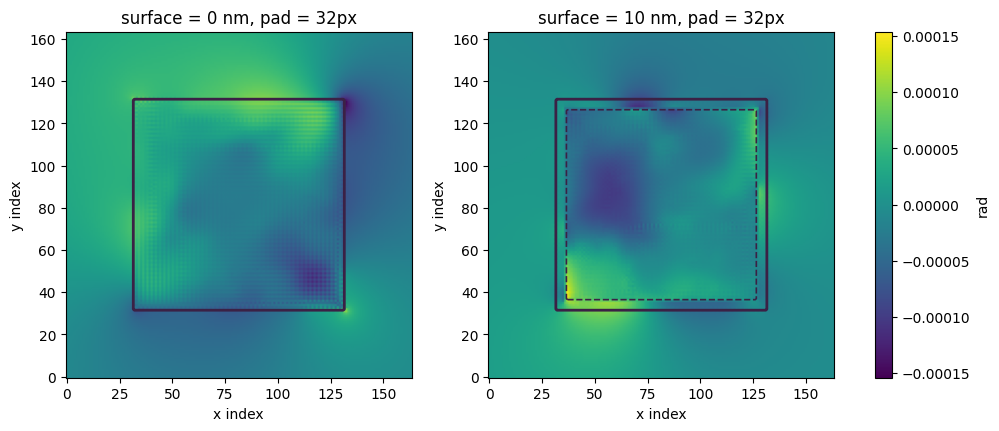

In [ ]:
def plot_phase_comparison(results):
    if not results:
        print("No comparison results to plot.")
        return
    phase_lim = max(max(abs(r["phase"].min()), abs(r["phase"].max())) for r in results)
    fig, axs = plt.subplots(1, len(results), figsize=(5.0 * len(results), 4.2), constrained_layout=True)
    if len(results) == 1:
        axs = [axs]
    for ax, result in zip(axs, results):
        im = ax.imshow(result["phase"], cmap="viridis", vmin=-phase_lim, vmax=phase_lim)
        result_config = result.get("config", config)
        support = np.max(result["core_weight"] + result["surface_weight"], axis=2)
        inner = np.max(hard_inner_cube_mask(result["surface_nm"], result_config), axis=2)
        ax.contour(pad_phase_mask_yx(support, result_config), levels=[0.5], colors=["#3b2145"], linewidths=2.0)
        if result["surface_nm"] > 0:
            ax.contour(pad_phase_mask_yx(inner, result_config), levels=[0.5], colors=["#3b2145"], linewidths=1.2, linestyles="--")
        ax.set_title(f"surface = {result['surface_nm']:.0f} nm, pad = {result_config.phase_pad_px}px")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
    fig.colorbar(im, ax=axs, fraction=0.046, label="rad")
    plt.show()


plot_phase_comparison(comparison_results if comparison_results else debug_results)

## Differentiable phase fit

This section fits `Ms_surface` and the MuMax-style `surface_nm` shell parameter against a phase image. The default target is synthetic, generated by the same forward path. Replace `target_phase_yx` with a measured phase image of the same shape to fit data.

In [ ]:
fit_config = debug_config
fit_target_surface_nm = 5.0
fit_target_ms_surface = 100e3
fit_initial_surface_nm = 4.0
fit_initial_ms_surface = 180e3
fit_inner_steps = 32
fit_outer_steps = 12
fit_learning_rate = 0.04

ms_surface_min = 10e3
ms_surface_max = fit_config.ms_core_a_per_m
surface_min_nm = 0.0
surface_max_nm = min(20.0, fit_config.d_total_nm - 2.0)


def logit_from_fraction(fraction):
    fraction = np.clip(float(fraction), 1e-6, 1.0 - 1e-6)
    return np.log(fraction / (1.0 - fraction))


def theta_from_bounded(value, lower, upper):
    return logit_from_fraction((float(value) - float(lower)) / (float(upper) - float(lower)))


def bounded_from_theta(theta, lower, upper):
    return lower + (upper - lower) * jax.nn.sigmoid(theta)


def unpack_fit_params(theta):
    ms_surface = bounded_from_theta(theta[0], ms_surface_min, ms_surface_max)
    surface_nm = bounded_from_theta(theta[1], surface_min_nm, surface_max_nm)
    return ms_surface, surface_nm


# Synthetic target. Replace this array with a measured phase image with shape phase_view_shape(fit_config).
target_case = relax_cube_case(fit_target_surface_nm, fit_config, ms_surface_a_per_m=fit_target_ms_surface)
target_phase_yx = jnp.asarray(target_case["phase"], dtype=jnp.float64)

# Fixed seed for the fit. The material fields, not the seed, carry the differentiable shell parameters.
fit_seed_m = make_initial_magnetization(fit_initial_surface_nm, fit_config)
_, _, fit_seed_ms, fit_seed_kc = material_fields_np(fit_initial_surface_nm, fit_initial_ms_surface, fit_config)
fit_state = build_state_template(fit_config, fit_seed_m, fit_seed_ms, fit_seed_kc)
fit_minimizer = make_minimizer(fit_state, fit_config, parameterized=True)
fit_m0 = jnp.asarray(fit_seed_m, dtype=jnp.float64)
fit_rdfc_kernel = build_rdfc_kernel(phase_view_shape(fit_config), geometry="disc", dtype=jnp.float64)


@jax.jit
def fit_loss(theta):
    ms_surface, surface_nm = unpack_fit_params(theta)
    _, _, ms_field, kc_field = material_fields_jax(surface_nm, ms_surface, fit_config)
    m_final = fit_minimizer.solve_fixed(
        fit_m0,
        ms_field,
        kc_field,
        steps=fit_inner_steps,
        return_info=False,
        checkpoint=True,
    )
    phase_pred = phase_from_cell_m_jax(m_final, ms_field, fit_config, rdfc_kernel=fit_rdfc_kernel)
    residual = phase_pred - target_phase_yx
    loss = 0.5 * jnp.mean(residual * residual)
    aux = {
        "ms_surface": ms_surface,
        "surface_nm": surface_nm,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_final": m_final,
    }
    return loss, aux


fit_value_and_grad = jax.jit(jax.value_and_grad(fit_loss, has_aux=True))

theta = jnp.asarray(
    [
        theta_from_bounded(fit_initial_ms_surface, ms_surface_min, ms_surface_max),
        theta_from_bounded(fit_initial_surface_nm, surface_min_nm, surface_max_nm),
    ],
    dtype=jnp.float64,
)

# Compile once and verify finite gradients.
(warm_loss, warm_aux), warm_grad = fit_value_and_grad(theta)
warm_loss.block_until_ready()
print(
    f"warmup loss={float(warm_loss):.6g}, rms={float(warm_aux['phase_rms']):.6g}, "
    f"Ms_surface={float(warm_aux['ms_surface']):.1f}, surface={float(warm_aux['surface_nm']):.3f}, "
    f"grad={np.asarray(warm_grad)}"
)

2026-04-28 13:48:53 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-28 13:48:53 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 13:48:53 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-28 13:48:53 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-28 13:48:53 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-28 13:48:53 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-28 13:48:55 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-28 13:48:55 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-28 13:49:00 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energy E = 3.79232e-17 J
2

warmup loss=0.00052393, rms=0.0323707, Ms_surface=180000.0, surface=4.000, grad=[-0.00087 -0.0023 ]


In [ ]:
optimizer = optax.adam(fit_learning_rate)
opt_state = optimizer.init(theta)
fit_history = []

started = time.perf_counter()
for step in range(fit_outer_steps + 1):
    (loss_value, aux_value), grad_value = fit_value_and_grad(theta)
    loss_value.block_until_ready()
    row = {
        "step": step,
        "loss": float(loss_value),
        "phase_rms": float(aux_value["phase_rms"]),
        "ms_surface": float(aux_value["ms_surface"]),
        "surface_nm": float(aux_value["surface_nm"]),
        "per_face_shell_nm": float(aux_value["surface_nm"]) / 2.0,
        "grad_norm": float(jnp.linalg.norm(grad_value)),
        "elapsed_s": time.perf_counter() - started,
    }
    fit_history.append(row)
    print(
        f"step={step:03d} loss={row['loss']:.6g} rms={row['phase_rms']:.6g} "
        f"Ms_surface={row['ms_surface'] / 1e3:.2f} kA/m "
        f"surface={row['surface_nm']:.3f} nm grad={row['grad_norm']:.3g}"
    )
    if step < fit_outer_steps:
        updates, opt_state = optimizer.update(grad_value, opt_state, theta)
        theta = optax.apply_updates(theta, updates)

_, fit_final_aux = fit_loss(theta)
fit_phase_pred = np.asarray(jax.device_get(fit_final_aux["phase_pred"]), dtype=np.float64)
fit_target_phase = np.asarray(jax.device_get(target_phase_yx), dtype=np.float64)
fit_residual = fit_phase_pred - fit_target_phase

np.savez_compressed(
    output_dir / "cube_surface_fit_debug.npz",
    target_phase=fit_target_phase,
    predicted_phase=fit_phase_pred,
    residual=fit_residual,
    history=np.array(fit_history, dtype=object),
)

In [ ]:
if fit_history:
    steps = np.array([row["step"] for row in fit_history])
    rms = np.array([row["phase_rms"] for row in fit_history])
    ms = np.array([row["ms_surface"] for row in fit_history])
    surface = np.array([row["surface_nm"] for row in fit_history])

    fig, axs = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
    axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o")
    axs[0].set_title("phase RMS")
    axs[0].set_xlabel("optimizer step")
    axs[0].set_ylabel("rad")
    axs[0].grid(True, alpha=0.25)

    axs[1].plot(steps, ms / 1e3, marker="o")
    axs[1].axhline(fit_target_ms_surface / 1e3, color="k", ls="--", lw=1.0)
    axs[1].set_title("Ms surface")
    axs[1].set_xlabel("optimizer step")
    axs[1].set_ylabel("kA/m")
    axs[1].grid(True, alpha=0.25)

    axs[2].plot(steps, surface, marker="o", label="MuMax parameter")
    axs[2].plot(steps, surface / 2.0, marker="s", label="per face")
    axs[2].axhline(fit_target_surface_nm, color="k", ls="--", lw=1.0)
    axs[2].set_title("surface thickness")
    axs[2].set_xlabel("optimizer step")
    axs[2].set_ylabel("nm")
    axs[2].grid(True, alpha=0.25)
    axs[2].legend()
    plt.show()

    phase_lim = max(abs(fit_target_phase).max(), abs(fit_phase_pred).max(), 1e-12)
    resid_lim = max(abs(fit_residual).max(), 1e-12)
    fig, axs = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)
    im0 = axs[0].imshow(fit_target_phase, cmap="viridis", vmin=-phase_lim, vmax=phase_lim)
    axs[0].set_title("target phase")
    axs[1].imshow(fit_phase_pred, cmap="viridis", vmin=-phase_lim, vmax=phase_lim)
    axs[1].set_title("fit phase")
    im2 = axs[2].imshow(fit_residual, cmap="RdBu_r", vmin=-resid_lim, vmax=resid_lim)
    axs[2].set_title("residual")
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(im0, ax=axs[:2], fraction=0.046, label="rad")
    fig.colorbar(im2, ax=[axs[2]], fraction=0.046, label="rad")
    plt.show()